In [1]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim import Optimizer
import os
import torch.nn.functional as F
import seaborn as sns
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim import Optimizer
import os
import matplotlib.pyplot as pltё
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        self.output = input
        return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        self.gradInput = gradOutput
        return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})


        Just write a little loop.
        """

        # Your code goes here. ################################################
        self.output = input 
        for module in self.modules: 
            self.output = module.forward(self.output)
        return self.output
    

    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)


        !!!

        To ech module you need to provide the input, module saw while forward pass,
        it is used while computing gradients.
        Make sure that the input for `i-th` layer the output of `module[i]` (just the same input as in forward pass)
        and NOT `input` to this Sequential module.

        !!!

        """
        # Your code goes here. ################################################
        grad = gradOutput
        for i in range(len(self.modules) -1, -1, -1):
            if i == 0:
                layer_grad = input
            else:
                layer_grad = self.modules[i-1].output
            grad = self.modules[i].backward(layer_grad, grad)
        self.gradInput = grad
        return self.gradInput



    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        """
        Should gather all parameters in a list.
        """
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules
        """
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.dot(input, self.W.T) + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = np.dot(gradOutput, self.W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradW += np.dot(gradOutput.T, input)
        self.gradb += np.sum(gradOutput, axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        
        # Your code goes here. ################################################
        degree = np.exp(self.output)
        self.output = degree/sum(degree,axis = 1,keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        s = self.output
        dot = np.sum(gradOutput*s,axis=1,keepdims=True)
        self.gradInput = s * (gradOutput - dot)
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

In [6]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        values = np.exp(self.output)
        sum = values.sum(axis=1, keepdims=True)
        self.output = values/sum
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        softmax = self.output
        grad_softmax = gradOutput * softmax
        sum_grad_softmax = grad_softmax.sum(axis=1, keepdims = True)
        grad_minus_sum = gradOutput- sum_grad_softmax
        self.gradInput = softmax * grad_minus_sum
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [7]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        degree = np.exp(self.output)
        log = np.log(np.sum(degree, axis = 1, keepdims = True))
        self.output = self.output - log
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        softmax_out = np.exp(self.output)
        self.gradInput = gradOutput - softmax_out * np.sum(gradOutput, axis=1, keepdims=True)
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization 
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [8]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        # use self.EPS please
        if (self.training == True):
            batch_mean = np.mean(input, axis=0)
            batch_variance = np.var(input, axis=0)
            if self.moving_mean is None:
                self.moving_mean = batch_mean
                self.moving_variance = batch_variance
            else:
                self.moving_mean = self.moving_mean * self.alpha + batch_mean * (1 - self.alpha)
                self.moving_variance = self.moving_variance * self.alpha + batch_variance * (1 - self.alpha)
            self.var_sqrt = np.sqrt(batch_variance+self.EPS)
            self.cen = input-batch_mean
            self.output = self.cen/self.var_sqrt
        else:
            self.output = (input-self.moving_mean)/np.sqrt(self.moving_variance+self.EPS)
            
        return self.output
        

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
       if (self.training == True):
        N = input.shape[0]
        a = N*gradOutput
        b = np.sum(gradOutput, axis=0)
        c = self.output*np.sum(gradOutput * self.output, axis=0)
        self.gradInput = (a-b-c)/(N*self.var_sqrt)
       else: 
        self.gradInput = gradOutput/np.sqrt(self.moving_variance+self.EPS)
       return self.gradInput
        

    def __repr__(self):
        return "BatchNormalization"

In [9]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/5y/2_x1w6jj22x17l6mcp8_2y7m0000gn/T/ipykernel_33069/3092293347.py:3: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [10]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if (self.training == True):
            self.mask = (np.random.rand(*input.shape)>self.p)/(1.0-self.p)
            self.output = input*self.mask
        else:
            self.output = input
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        if (self.training == True):
            self.gradInput = gradOutput*self.mask
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding = valid/same, bias, padding_mode = zero) and fix dilation=1 and groups=1.

In [11]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * scale
        self.gradW = np.zeros_like(self.W)

        if self.bias:
            self.b = np.zeros(out_channels)
            self.gradb = np.zeros(out_channels)
        else:
            self.b = None
            self.gradb = None

    def updateOutput(self, input):
        N, C, H, W = input.shape
        K = self.kernel_size
        if self.padding == 'same':
            pad = (K - 1) // 2
        else:
            pad = self.padding
            
        self.current_pad = pad
        OH = (H + 2 * pad - K) // self.stride + 1
        OW = (W + 2 * pad - K) // self.stride + 1
        self.input_padded = np.pad(input, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')
        self.output = np.zeros((N, self.out_channels, OH, OW))
        for i in range(OH):
            for j in range(OW):
                hs, ws = i * self.stride, j * self.stride
                patch = self.input_padded[:, :, hs:hs+K, ws:ws+K]
                for k in range(self.out_channels):
                    self.output[:, k, i, j] = np.sum(patch * self.W[k], axis=(1, 2, 3))
                    
        if self.bias:
            self.output += self.b[None, :, None, None]
            
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        _, out_C, OH, OW = gradOutput.shape
        K = self.kernel_size
        pad = self.current_pad
        self.gradW.fill(0)
        if self.bias:
            self.gradb = np.sum(gradOutput, axis=(0, 2, 3))
            
        g_in_padded = np.zeros_like(self.input_padded)
        for i in range(OH):
            for j in range(OW):
                hs, ws = i * self.stride, j * self.stride
                patch = self.input_padded[:, :, hs:hs+K, ws:ws+K]
                for k in range(out_C):
                    go = gradOutput[:, k, i, j][:, None, None, None]
                    self.gradW[k] += np.sum(patch * go, axis=0)
                    g_in_padded[:, :, hs:hs+K, ws:ws+K] += self.W[k] * go
        if pad > 0:
            self.gradInput = g_in_padded[:, :, pad:-pad, pad:-pad]
        else:
            self.gradInput = g_in_padded
            
        return self.gradInput

    def getParameters(self):
        return [self.W, self.b] if self.bias else [self.W]

    def getGradParameters(self):
        return [self.gradW, self.gradb] if self.bias else [self.gradW]

    def zeroGradParameters(self):
        self.gradW.fill(0)
        if self.bias:
            self.gradb.fill(0)


#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [12]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
         # Your code goes here. ################################################
        N, C, H, W = input.shape
        KH = KW = self.kernel_size
        SH = SW = self.stride
        pad = self.padding
        input_padded = np.pad(input,((0,0),(0,0),(pad,pad),(pad,pad)),mode='constant', constant_values=-np.inf)
        OH = (H+2*pad-KH)//SH+1
        OW = (W+2*pad-KW)//SW+1
        self.output = np.zeros((N, C, OH, OW))
        self.mask = np.zeros_like(input_padded)
        for i in range(OH):
            for j in range(OW):
                hs, ws = i*SH, j*SW
                patch = input_padded[:, :, hs:hs+KH, ws:ws+KW]
                max_val = np.max(patch, axis=(2,3))
                self.output[:, :, i, j] = max_val
                mask = (patch == max_val[:, :, None, None])
                self.mask[:, :, hs:hs+KH, ws:ws+KW] += mask

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        N, C, H, W = input.shape
        KH = KW = self.kernel_size
        SH = SW = self.stride
        pad = self.padding
        grad_input_padded = np.zeros_like(self.mask)
        a, b, OH, OW = gradOutput.shape
        for i in range(OH):
            for j in range(OW):
                hs, ws = i*SH, j*SW
                grad = gradOutput[:, :, i, j][:, :, None, None]
                mask = self.mask[:, :, hs:hs+KH, ws:ws+KW]
                grad_input_padded[:, :, hs:hs+KH, ws:ws+KW] += mask * grad
        if pad > 0:
            self.gradInput = grad_input_padded[:, :, pad:-pad, pad:-pad]
        else:
            self.gradInput = grad_input_padded

        return self.gradInput


    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        # Your code goes here. ################################################
        N, C, H, W = input.shape
        KH = KW = self.kernel_size
        SH = SW = self.stride
        pad = self.padding
        input_padded = np.pad(input,((0,0),(0,0),(pad,pad),(pad,pad)), mode='constant')
        OH = (H+2*pad-KH)//SH+1
        OW = (W+2*pad-KW)//SW+1
        self.output = np.zeros((N, C, OH, OW))
        for i in range(OH):
            for j in range(OW):
                hs, ws = i*SH, j*SW
                patch = input_padded[:, :, hs:hs+KH, ws:ws+KW]
                self.output[:, :, i, j] = np.mean(patch, axis=(2,3))

        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        N, C, H, W = input.shape
        KH = KW = self.kernel_size
        SH = SW = self.stride
        pad = self.padding
        grad_input_padded = np.zeros((N,C,H+2*pad,W+2*pad))
        a, b, OH, OW = gradOutput.shape
        for i in range(OH):
            for j in range(OW):
                hs, ws = i*SH, j*SW
                grad = gradOutput[:, :, i, j][:, :, None, None] / (KH * KW)
                grad_input_padded[:, :, hs:hs+KH, ws:ws+KW] += grad
        if pad > 0:
            self.gradInput = grad_input_padded[:, :, pad:-pad, pad:-pad]
        else:
            self.gradInput = grad_input_padded

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [13]:
class GlobalMaxPool2d(Module):
    def updateOutput(self, input):
        self.output = np.max(input, axis=(2, 3))
        return self.output

    def updateGradInput(self, input, gradOutput):
        mask = (input == self.output[:, :, None, None])
        self.gradInput = mask * gradOutput[:, :, None, None]
        return self.gradInput
        
    def __repr__(self):
        return "GlobalMaxPool2d"

In [14]:
class GlobalAvgPool2d(Module):
    def updateOutput(self, input):
        self.output = np.mean(input, axis=(2, 3))
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        size = H*W
        self.gradInput = np.ones((N, C, H, W))*(gradOutput[:, :, None, None]/size)
        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"


In [15]:
def test_global_layers():
    x = np.array([[[[1, 2], [3, 4]]]], dtype=float)
    y = np.array([[1.0]]) 
    max_layer = GlobalMaxPool2d()
    print(f"Max Output: {max_layer.forward(x)}") 
    print(f"Max Grad:\n{max_layer.backward(x, y)}") 
    avg_layer = GlobalAvgPool2d()
    print(f"Avg Output: {avg_layer.forward(x)}") 
    print(f"Avg Grad:\n{avg_layer.backward(x, y)}")

test_global_layers()


Max Output: [[4.]]
Max Grad:
[[[[0. 0.]
   [0. 1.]]]]
Avg Output: [[2.5]]
Avg Grad:
[[[[0.25 0.25]
   [0.25 0.25]]]]


#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [16]:
class Flatten(Module):
    def __init__(self, start_dim=1, end_dim=-1): # ИСПРАВЛЕНО: start_dim=1 по умолчанию
        super(Flatten, self).__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        self.input_shape = input.shape
        
        # Обработка отрицательных индексов для end_dim
        actual_end_dim = self.end_dim
        if actual_end_dim < 0:
            actual_end_dim = len(input.shape) + actual_end_dim
            
        # Считаем размерность, в которую превращаются выбранные оси
        flatten_dim = np.prod(input.shape[self.start_dim : actual_end_dim + 1])
        
        # Формируем новый shape: оставляем начало, вставляем flatten_dim, оставляем конец
        new_shape = input.shape[:self.start_dim] + (int(flatten_dim),) + input.shape[actual_end_dim + 1:]
        
        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Возвращаем градиент к исходной форме тензора
        self.gradInput = gradOutput.reshape(self.input_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"


# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [17]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [18]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input >= 0,input, input*self.slope)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        grad = np.where(input >= 0,1,self.slope)
        self.gradInput = gradOutput * grad
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [19]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input,self.alpha*(np.exp(input)-1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        grad = np.where(input > 0, 1, self.output+self.alpha)
        self.gradInput = gradOutput * grad
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [20]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.log(1+np.exp(input))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        sigmoid = 1/(1+np.exp(-input))
        self.gradInput = gradOutput*sigmoid
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations. 


In [21]:
class Gelu(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.input = input
        const_1 = np.sqrt(2/np.pi)
        const_2 = 0.044715
        self.inn = const_1*(input+const_2*np.power(input, 3))
        self.tanh_out = np.tanh( self.inn)
        self.output = 0.5*input*(1+self.tanh_out)

        return self.output
 

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        const_1 = np.sqrt(2/np.pi)
        const_2 = 0.044715
        delts_tanh = (1-self.tanh_out**2)*const_1*(1+3*const_2*input**2)
        self.gradInput = gradOutput*(0.5*(1+self.tanh_out)+0.5*input*delts_tanh)
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [22]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [23]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [24]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1-self.EPS)

        # Your code goes here. ################################################
        log_probs = np.log(input_clamp)
        self.output = -np.sum(target*log_probs)/input.shape[0] 
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1-self.EPS)

        # Your code goes here. ################################################
        self.gradInput = -target/(input_clamp*input.shape[0])
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [25]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        self.output = -np.sum(target * input)/input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        self.gradInput = -target/input.shape[0] 
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.


### Реализация стохастического градиентного спуска

In [26]:
class SGD:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def step(self):
        with torch.no_grad():
            for p, v in zip(self.params, self.velocities):
                v.copy_(self.momentum * v + p.grad)
                p -= self.lr * v

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()
X_reg = torch.randn(1000, 10)
y_reg = X_reg @ torch.randn(10, 3) + 0.5

class Regression(nn.Module):
    def __init__(self, size='medium'):
        super().__init__()
        sizes = {'small': [16], 'medium': [64, 32], 'large': [256, 128, 64]}
        layers = []
        in_dim = 10
        for h in sizes[size]:
            layers.extend([nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2)])
            in_dim = h
        layers.append(nn.Linear(in_dim, 3))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential( nn.Flatten(), nn.Linear(32 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10), nn.LogSoftmax(dim=1))

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(0.1), nn.Flatten(), nn.Linear(16 * 14 * 14, 64))
        self.decoder = nn.Sequential(nn.Linear(64, 16 * 14 * 14),nn.ReLU(),nn.Unflatten(1, (16, 14, 14)),nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

model_reg = Regression(size='large')
model_cls = MNIST()
model_ae = Encoder()

optimizer_reg = SGD(model_reg.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()
criterion_cls = nn.NLLLoss()


In [31]:
class SGD_1(Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.9):
        defaults = dict(lr=lr, momentum=momentum)
        super(SGD_1, self).__init__(params, defaults)

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            momentum = group['momentum']
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if 'velocity' not in state:
                    state['velocity'] = torch.zeros_like(p.data)
                
                v = state['velocity']
                v.copy_(momentum * v + p.grad.data)
                p.data.add_(v, alpha=-lr)
        return loss

class Scheduler(lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_iters, main_scheduler, last_epoch=-1):
        self.warmup_iters = warmup_iters
        self.main_scheduler = main_scheduler
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_iters:
            return [base_lr * (self.last_epoch + 1) / self.warmup_iters for base_lr in self.base_lrs]
        return self.main_scheduler.get_lr()

    def step(self, epoch=None):
        if self.last_epoch >= self.warmup_iters:
            self.main_scheduler.step(epoch)
        super().step(epoch)


class Early_Stop:
    def __init__(self, patience=3, path='best_model.pt'):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.path = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


def Train(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler, epochs=5, is_ae=False):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    model_name = model.__class__.__name__
    save_path = f'best_{model_name}.pt'
    stopper = Early_Stop(patience=3, path=save_path)

    for epoch in range(epochs):
        model.train()
        train_total_loss = 0
        for x, y in train_loader:
            target = x if is_ae else y
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, target)
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item()
        
        scheduler.step()
        
        model.eval()
        val_total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                target = x if is_ae else y
                out = model(x)
                val_total_loss += criterion(out, target).item()
                
                if not is_ae and isinstance(criterion, nn.NLLLoss):
                    preds = out.argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)

        v_loss = val_total_loss / len(val_loader)
        history['train_loss'].append(train_total_loss / len(train_loader))
        history['val_loss'].append(v_loss)
        if total > 0: history['val_acc'].append(correct / total)

        print(f"Epoch {epoch+1}: Val Loss: {v_loss:.4f}" + (f" | Acc: {correct/total:.4f}" if total > 0 else ""))
        if stopper(v_loss, model): 
            print("ранний стоп")
            break



    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            target = x if is_ae else y
            out = model(x)
            test_loss += criterion(out, target).item()


In [32]:
mnist_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_ds, val_ds = torch.utils.data.random_split(mnist_full, [50000, 10000])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(mnist_test, batch_size=64)

opt_cls = SGD_1(model_cls.parameters(), lr=0.01)
base_sched_cls = lr_scheduler.ExponentialLR(opt_cls, gamma=0.9)
sched_cls = Scheduler(opt_cls, warmup_iters=2, main_scheduler=base_sched_cls)

Train(model_cls, train_loader, val_loader, test_loader, criterion_cls, opt_cls, sched_cls)
opt_ae = SGD_1(model_ae.parameters(), lr=0.01)
base_sched_ae = lr_scheduler.StepLR(opt_ae, step_size=3, gamma=0.1)
sched_ae = Scheduler(opt_ae, warmup_iters=2, main_scheduler=base_sched_ae)
criterion_ae = nn.MSELoss()
Train(model_ae, train_loader, val_loader, test_loader, criterion_ae, opt_ae, sched_ae, is_ae=True)

Epoch 1: Val Loss: 0.0294 | Acc: 0.9903


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:1060: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch 2: Val Loss: 0.0350 | Acc: 0.9878
Epoch 3: Val Loss: 0.0332 | Acc: 0.9888
Epoch 4: Val Loss: 0.0317 | Acc: 0.9897
ранний стоп
Epoch 1: Val Loss: 0.5121


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:656: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch 2: Val Loss: 0.5058
Epoch 3: Val Loss: 0.5016
Epoch 4: Val Loss: 0.4980
Epoch 5: Val Loss: 0.4955


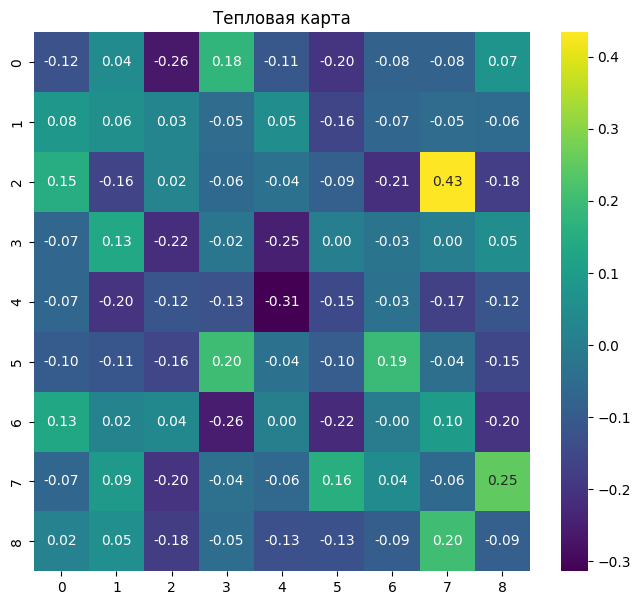

In [33]:
def warm_map(dataset, color_palette='viridis'):
    n = 9
    list = []
    for i in range(n * n):
        a, b = dataset[i]
        avg_intensity = a.mean().item()
        list.append(avg_intensity)
    map = np.array(list).reshape(n, n)
    plt.figure(figsize=(8, 7))
    sns.heatmap(map, annot=True, fmt=".2f", cmap=color_palette)
    plt.title(f"Тепловая карта")
    plt.show()
warm_map(mnist_test, color_palette='viridis')

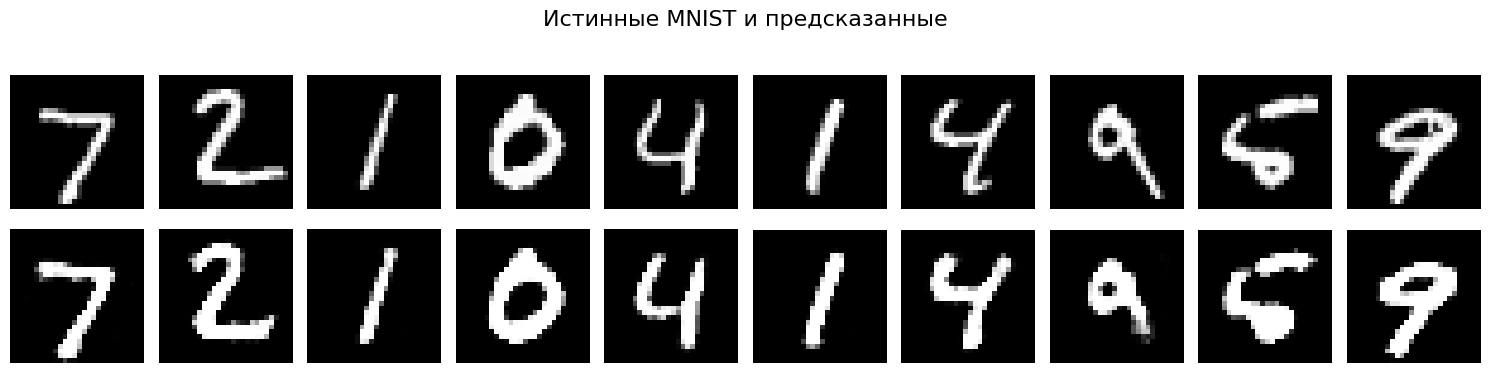

In [34]:
def mnist_dataloader(model, dataset, num_samples=10):
    model.eval()
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 4))  
    for i in range(num_samples):
        a, b = dataset[i]
        with torch.no_grad():
            reconstructed = model(a.unsqueeze(0))

        axes[0, i].imshow(a.squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed.squeeze().cpu(), cmap='gray')
        axes[1, i].axis('off')
    
    plt.suptitle("Истинные MNIST и предсказанные", fontsize=16)
    plt.tight_layout()
    plt.show()
mnist_dataloader(model_ae, mnist_test)
